# Bayesian Structural Causal Models: model construction
## Update & load packages

In [1]:
# data manipulation
using CSV, DataFrames, Query
using LazyArrays

# modelling
using HypothesisTests
using GLM
using Dagitty
using StatisticalRethinking, StructuralCausalModels

# plotting & diagnostics
using StatsPlots

default(labels=false)
print("Running on ", Threads.nthreads(), " threads.")

Running on 4 threads.

## Construct Causal Model

![DAG](../Apodemus-vacc-DAGs/DAG.jpg)

In [2]:
dag = Dagitty.DAG(
:D => :E,
:D => :F,
:D => :M,
:D => :P,
:D => :R,
:F => :E,
:F => :M,
:M => :E,
:P => :E,
# :P => :F,
# :P => :M,
:P => :R,
:R => :E,
:R => :F,
:R => :M,
:S => :E,
:S => :F,
:S => :M,
:S => :P,
:S => :R,
:T => :E,
:T => :F,
:T => :M,
:T => :R,
:V => :E,
:V => :T,
:W => :E,
:W => :F,
:W => :M,
:W => :P,
:W => :R,
:W => :T,
)

DAG: {10, 30} directed simple Int64 graph with labels [:D, :E, :F, :M, :P, :R, :S, :T, :V, :W])


## Validate model structure using observed data

We shall use GLMs to ensure there is no grave violation of our assumptions.

### Import data

In [3]:
rawdata = CSV.File("../data/joint_dataset_4analysis.csv";
    missingstring = "NA", pool = true) |>
    DataFrame

,Plate,Measure,Row,Col_5,Col_6,Col_7,Blank,ID,Block,Sex
,Int64,Int64,String1,Float64,Float64,Float64,Float64,Int64?,Int64?,String1?
1,18,1,G,2.59,2.005,1.397,0.069,1,1,M
2,9,1,D,2.498,2.189,1.762,0.079,2,1,M
3,11,1,G,2.981,2.674,2.439,0.069,2,1,M
4,27,1,G,0.888,0.537,0.355,0.107,2,1,M
5,36,1,E,2.042,1.613,1.112,0.087,2,1,M
6,4,1,C,1.362,0.912,0.538,0.061,3,1,M
7,5,1,F,0.049,0.06,0.054,0.075,3,1,M
8,16,1,H,0.063,0.071,0.066,0.084,3,1,M
9,5,1,H,1.04,0.638,0.36,0.066,4,1,M


### Clean data

Will remove NAs for now; imputation will be attempted once the structure of the DAG is better ascertained.

In [4]:
dataclean =
    rawdata |>
    @dropna(:ID) |> # remove entries which lack lab ID or PIT tag IDs (cannot be imputed)
    @filter(_.vax_history != "DD") |> # keep only mice with a single vaccination or adjuvant
    @filter(_.days_since_1st_D_or_A > 7) |> # remove entries which were measured less than a week after vaccination
    @dropna(:Diet) |> # remove entries which lack a Diet value  (should be imputed)
    @dropna(:repro_bin) |> # remove entries which lack a repro value  (should be imputed)
    @dropna(:Weight) |> # remove entries which lack a body mass measurement (should be imputed)
    @dropna(:Fat_Scores_Sum) |> # drop missing fat scores  (should be imputed)
    # @filter(_.OD > 0) |> # remove individuals who didn't seroconvert
    DataFrame

,Plate,Measure,Row,Col_5,Col_6,Col_7,Blank,ID,Block,Sex
,Int64,Int64,String1,Float64,Float64,Float64,Float64,Int64,Int64?,String1?
1,27,1,G,0.888,0.537,0.355,0.107,2,1,M
2,36,1,E,2.042,1.613,1.112,0.087,2,1,M
3,5,1,F,0.049,0.06,0.054,0.075,3,1,M
4,16,1,H,0.063,0.071,0.066,0.084,3,1,M
5,27,1,F,0.066,0.086,0.066,0.102,4,1,M
6,1,1,F,1.593,1.051,0.662,0.067,5,1,M
7,32,1,D,1.093,0.712,0.429,0.108,5,1,M
8,7,1,E,1.53,1.107,0.711,0.079,6,1,M
9,19,1,D,1.56,1.077,0.661,0.118,6,1,M


In [5]:
# select only the last complete entry for each mouse
dataunique = dataclean |>
             @groupby(_.ID) |>
             @map({ID = key(_), days_since_1st_D_or_A = maximum(_.days_since_1st_D_or_A)}) |>
             DataFrame;

In [6]:
# join the rest of the columns
data = dataclean |>
       @join(dataunique, _.ID, _.ID, {_..., __...}) |>
       @unique(_.ID) |> # ensure no repeated measures
       DataFrame;
"Total number of individual wood mice: $(length(unique(data.ID)))"

"Total number of individual wood mice: 99"

In [7]:
describe(data)

,variable,mean,min,median,max,nmissing
,Symbol,Union…,Any,Union…,Any,Int64
1,Plate,12.4949,1,12.0,37,0
2,Measure,1.0,1,1.0,1,0
3,Row,,C,,H,0
4,Col_5,1.11745,0.047,1.235,2.638,0
5,Col_6,0.797576,0.046,0.7,2.396,0
6,Col_7,0.550323,0.048,0.478,1.931,0
7,Blank,0.0903434,0.052,0.068,0.695,0
8,ID,3.04956e8,2,59.0,841265814,0
9,Block,1.52381,1,2.0,2,36


### Encode & standardise features

In [8]:
# create log OD response variable
data.logOD = log.(10, 1 .+ data.OD)
# encoding
data.ismale = data.Sex .∈ Ref(["M"])
data.issupplemented = data.Diet .∈ Ref(["High"])
data.isreproductive = data.repro_bin .∈ Ref(["Reproductive"])
data.iswild = data.Env .∈ Ref(["Wild"])

# populate nodes
# data.E = standardize(ZScoreTransform, data.logOD)
# data.W = @. ifelse(data.Env == "Wild", 1, 2)
# data.V = @. ifelse(data.isvax == 1, 1, 2)
# data.D = @. ifelse(data.Diet == "High", 1, 2)
# data.R = @. ifelse(data.repro_bin == "Reproductive", 1, 2)
# data.S = @. ifelse(data.Sex == "M", 1, 2)
# data.M = standardize(ZScoreTransform, data.Weight)
# data.F = data.Fat_Scores_Sum
# data.T = data.days_since_1st_D_or_A
# data.P = @. ifelse(data.isHp == 0, 1, 2)
# data.nP = data.nHp;

# binary version
data.E = standardize(ZScoreTransform, data.logOD)
data.M = standardize(ZScoreTransform, data.Weight)
data.F = data.Fat_Scores_Sum
data.T = data.days_since_1st_D_or_A
data.W = data.Env .∈ Ref(["Wild"])
data.V = data.isvax
data.D = data.Diet .∈ Ref(["High"])
data.R = data.repro_bin .∈ Ref(["Reproductive"])
data.S = data.Sex .∈ Ref(["M"])
data.P = data.isHp
data.nP = data.nHp;


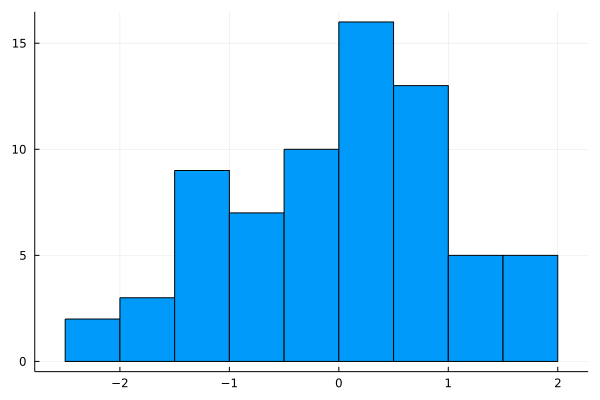

In [9]:
# Check that standardized logOD is a suitable transformation for immunised mice
seroconv = standardize(ZScoreTransform, data.E[data[!, :logOD] .> 0])

histogram(seroconv, bins=10)

In [10]:
ExactOneSampleKSTest(seroconv, Normal())

Exact one sample Kolmogorov-Smirnov test
----------------------------------------
Population details:
    parameter of interest:   Supremum of CDF differences
    value under h_0:         0.0
    point estimate:          0.0974188

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.4896

Details:
    number of observations:   70


### Select features used in DAG

In [11]:
# We're using this DAG:
dag

DAG: {10, 30} directed simple Int64 graph with labels [:D, :E, :F, :M, :P, :R, :S, :T, :V, :W])


In [12]:
dag_df = data[!, [:E, :W, :V, :D, :R, :S, :M, :F, :T, :P, :nP]]
# Convert 1 / 0 to true / false
dag_df[!, :V] = convert(Vector{Bool}, dag_df[!, :V])
dag_df[!, :P] = convert(Vector{Bool}, dag_df[!, :P])
describe(dag_df)

,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,Type
1,E,8.74721e-17,-1.23819,0.120087,1.81173,0,Float64
2,W,0.363636,0,0.0,1,0,Bool
3,V,0.727273,0,1.0,1,0,Bool
4,D,0.525253,0,1.0,1,0,Bool
5,R,0.262626,0,0.0,1,0,Bool
6,S,0.535354,0,1.0,1,0,Bool
7,M,3.4316e-16,-1.93961,0.097152,3.1523,0,Float64
8,F,6.29798,4.0,7.0,9.5,0,Float64
9,T,20.3838,9,17.0,64,0,"Union{Missing, Int64}"


### Eyeball data
There are some missing values which it would be good to impute using the causal model before we test.

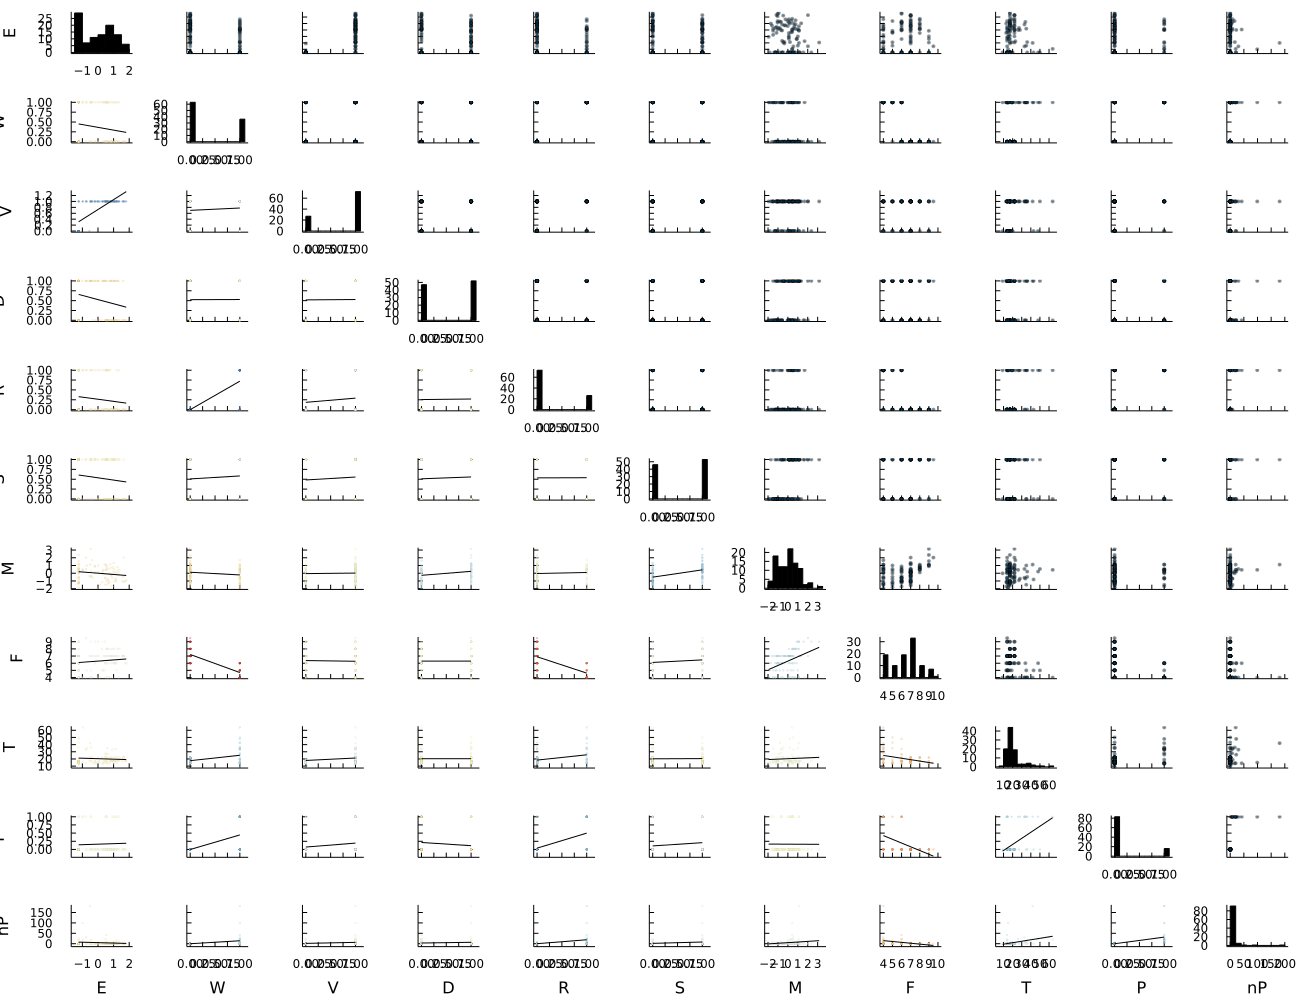

In [13]:
corrplot(Matrix(dag_df), size=(1300,1000), seriestype=:scatter, ms=2, bins=10,grid=false, labels=names(dag_df))

### Test conditional independencies

In [14]:
implied_conditional_independencies_min(dag)

15-element Vector{ConditionalIndependence}:
 ConditionalIndependence(:D, :S, Symbol[])
 ConditionalIndependence(:D, :T, Symbol[])
 ConditionalIndependence(:D, :V, Symbol[])
 ConditionalIndependence(:D, :W, Symbol[])
 ConditionalIndependence(:F, :P, [:D, :R, :S, :T, :W])
 ConditionalIndependence(:F, :V, [:T, :W])
 ConditionalIndependence(:M, :P, [:D, :R, :S, :T, :W])
 ConditionalIndependence(:M, :V, [:T, :W])
 ConditionalIndependence(:P, :T, [:W])
 ConditionalIndependence(:P, :V, Symbol[])
 ConditionalIndependence(:R, :V, [:T, :W])
 ConditionalIndependence(:S, :T, Symbol[])
 ConditionalIndependence(:S, :V, Symbol[])
 ConditionalIndependence(:S, :W, Symbol[])
 ConditionalIndependence(:V, :W, Symbol[])

#### D ⫫ S

In [15]:
glm(@formula(D~S), dag_df, Binomial())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

D ~ 1 + S

Coefficients:
──────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error     z  Pr(>|z|)  Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────
(Intercept)  8.20566e-17    0.294884  0.00    1.0000  -0.577962   0.577962
S            0.189242       0.403863  0.47    0.6394  -0.602315   0.980799
──────────────────────────────────────────────────────────────────────────

#### D ⫫ T

In [16]:
glm(@formula(D~T), dag_df, Binomial())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

D ~ 1 + T

Coefficients:
──────────────────────────────────────────────────────────────────────────
                  Coef.  Std. Error     z  Pr(>|z|)   Lower 95%  Upper 95%
──────────────────────────────────────────────────────────────────────────
(Intercept)  0.100664     0.508382   0.20    0.8430  -0.895746   1.09707
T            2.11933e-5   0.0229028  0.00    0.9993  -0.0448675  0.0449099
──────────────────────────────────────────────────────────────────────────

#### D ⫫ V

In [ ]:
glm(@formula(D~V), dag_df, Binomial())

#### D ⫫ W

In [18]:
glm(@formula(D~W), dag_df, Binomial())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

D ~ 1 + W

Coefficients:
────────────────────────────────────────────────────────────────────────
                 Coef.  Std. Error     z  Pr(>|z|)  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────────
(Intercept)  0.0953102    0.252262  0.38    0.7056  -0.399115   0.589735
W            0.0159155    0.418439  0.04    0.9697  -0.80421    0.836041
────────────────────────────────────────────────────────────────────────

#### F ⫫ P | D, R, S, T, W

In [ ]:
glm(@formula(F ~ P), dag_df, Normal())

In [19]:
glm(@formula(F ~ P + D + R + S + T + W), dag_df, Normal())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Normal{Float64}, IdentityLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

F ~ 1 + P + D + R + S + T + W

Coefficients:
────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error      z  Pr(>|z|)  Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)   6.95531      0.266395   26.11    <1e-99   6.43318    7.47743
P            -0.0892569    0.323094   -0.28    0.7824  -0.72251    0.543996
D            -0.0221971    0.182319   -0.12    0.9031  -0.379537   0.335142
R            -0.180096     0.339006   -0.53    0.5952  -0.844535   0.484343
S             0.531677     0.182545    2.91    0.0036   0.173896   0.889458
T             3.11415e-5   0.0116294   0.00    0.9979  -0.022762   0.0228243
W            -2.39033      0.319857   -7.47    <1e-13  -3.01724   -1

#### F ⫫ V | T, W

In [ ]:
glm(@formula(F ~ V), dag_df, Normal())

In [20]:
glm(@formula(F ~ V + T + W), dag_df, Normal())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Normal{Float64}, IdentityLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

F ~ 1 + V + T + W

Coefficients:
──────────────────────────────────────────────────────────────────────────────
                   Coef.  Std. Error       z  Pr(>|z|)   Lower 95%   Upper 95%
──────────────────────────────────────────────────────────────────────────────
(Intercept)   7.16726      0.260358    27.53    <1e-99   6.65697     7.67756
V             0.142851     0.209679     0.68    0.4957  -0.268113    0.553815
T            -0.00298842   0.0116159   -0.26    0.7970  -0.0257552   0.0197783
W            -2.50872      0.209839   -11.96    <1e-32  -2.91999    -2.09744
──────────────────────────────────────────────────────────────────────────────

#### M ⫫ P | D, R, S, T, W

In [ ]:
glm(@formula(M ~ P), dag_df, Normal())

In [21]:
glm(@formula(M ~ P + D + R + S + T + W), dag_df, Normal())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Normal{Float64}, IdentityLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

M ~ 1 + P + D + R + S + T + W

Coefficients:
────────────────────────────────────────────────────────────────────────────
                  Coef.  Std. Error      z  Pr(>|z|)   Lower 95%   Upper 95%
────────────────────────────────────────────────────────────────────────────
(Intercept)  -0.915175   0.227424    -4.02    <1e-04  -1.36092    -0.469432
P            -0.0076531  0.275829    -0.03    0.9779  -0.548267    0.532961
D             0.455639   0.155648     2.93    0.0034   0.150575    0.760704
R             1.25354    0.289413     4.33    <1e-04   0.686298    1.82077
S             1.01596    0.15584      6.52    <1e-10   0.710521    1.3214
T             0.0162231  0.00992811   1.63    0.1022  -0.0032356   0.0356819
W            -1.44847    0.273065    -5.30    <1e-06  -1.98366    -0.9

#### M ⫫ V | T, W

In [ ]:
glm(@formula(M ~ V), dag_df, Normal())

In [22]:
glm(@formula(M ~ V + T + W), dag_df, Normal())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Normal{Float64}, IdentityLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

M ~ 1 + V + T + W

Coefficients:
─────────────────────────────────────────────────────────────────────────────
                  Coef.  Std. Error      z  Pr(>|z|)    Lower 95%   Upper 95%
─────────────────────────────────────────────────────────────────────────────
(Intercept)  -0.229958    0.281476   -0.82    0.4139  -0.781641     0.321724
V             0.0519504   0.226687    0.23    0.8187  -0.392347     0.496248
T             0.0181048   0.0125581   1.44    0.1494  -0.00650851   0.0427182
W            -0.486393    0.226859   -2.14    0.0320  -0.931028    -0.041758
─────────────────────────────────────────────────────────────────────────────

#### P ⫫ T | W

In [ ]:
glm(@formula(P ~ T), dag_df, Binomial())

In [23]:
glm(@formula(P ~ T + W), dag_df, Binomial())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

P ~ 1 + T + W

Coefficients:
─────────────────────────────────────────────────────────────────────────────────
                   Coef.   Std. Error      z  Pr(>|z|)      Lower 95%   Upper 95%
─────────────────────────────────────────────────────────────────────────────────
(Intercept)  -16.42       182.792      -0.09    0.9284  -374.686       341.846
T              0.0482119    0.0293933   1.64    0.1010    -0.00939778    0.105822
W             14.9815     182.792       0.08    0.9347  -343.284       373.247
─────────────────────────────────────────────────────────────────────────────────

#### P ⫫ V 

In [ ]:
glm(@formula(P ~ V), dag_df, Binomial())

#### R ⫫ V | T, W

In [33]:
glm(@formula(R ~ V), dag_df, Binomial())

In [24]:
glm(@formula(R ~ V + T + W), dag_df, Binomial())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

R ~ 1 + V + T + W

Coefficients:
─────────────────────────────────────────────────────────────────────────────────
                   Coef.   Std. Error      z  Pr(>|z|)     Lower 95%    Upper 95%
─────────────────────────────────────────────────────────────────────────────────
(Intercept)  -16.2016     182.502      -0.09    0.9293  -373.898      341.495
V              0.550058     0.857671    0.64    0.5213    -1.13095      2.23106
T              0.0128853    0.0308523   0.42    0.6762    -0.0475841    0.0733546
W             16.4235     182.5         0.09    0.9283  -341.27       374.117
─────────────────────────────────────────────────────────────────────────────────

#### S ⫫ T

In [ ]:
glm(@formula(S~T), dag_df, Binomial())

#### S ⫫ V

In [26]:
glm(@formula(S~V), dag_df, Binomial())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

S ~ 1 + V

Coefficients:
─────────────────────────────────────────────────────────────────────────
                 Coef.  Std. Error      z  Pr(>|z|)  Lower 95%  Upper 95%
─────────────────────────────────────────────────────────────────────────
(Intercept)  -0.074108    0.385164  -0.19    0.8474  -0.829016     0.6808
V             0.297252    0.452328   0.66    0.5111  -0.589295     1.1838
─────────────────────────────────────────────────────────────────────────

#### S ⫫ W

In [ ]:
glm(@formula(S~W), dag_df, Binomial())

#### V ⫫ W

In [28]:
glm(@formula(V~W), dag_df, Binomial())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, Cholesky{Float64, Matrix{Float64}}}}, Matrix{Float64}}

V ~ 1 + W

Coefficients:
───────────────────────────────────────────────────────────────────────
                Coef.  Std. Error     z  Pr(>|z|)  Lower 95%  Upper 95%
───────────────────────────────────────────────────────────────────────
(Intercept)  0.839751    0.274516  3.06    0.0022   0.30171     1.37779
W            0.413012    0.485873  0.85    0.3953  -0.539282    1.36531
───────────────────────────────────────────────────────────────────────